# Team: Alexandro Galvez-Vega and Victor Neyra
# Class: CAP 5625-042 Computational Foundations Of AI
# Professor: Michael DeGiorgio

In [1]:
#Starting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

# Deliverables Are Located Below
# __________________________________________________________________
# __________________________________________________________________


In [2]:
#The previous assignment was used as a template
#Similar early logic exists
#Here, we are temporarily turning the csv data into a data frame

filename = "Credit_N400_p9.csv"
advertising_df = pd.read_csv(filename)

#This dataframe is quickly split between the features that will be used for x

x_features_df = advertising_df.copy(deep = True)


#Our goal is to determine credit card balance which is separated into its own df here

y_features_df = x_features_df.pop("Balance") 

In [3]:

#In this part the categorical columns are converted to allow them to be used for the upcoming alogirthms
x_features_df = pd.get_dummies(x_features_df, columns = ["Gender"], drop_first=True, dtype=int)

x_features_df = pd.get_dummies(x_features_df, columns = ["Married"], drop_first=True, dtype=int)

x_features_df = pd.get_dummies(x_features_df, columns = ["Student"], drop_first=True, dtype=int)

In [4]:
#This simply shows that the columns were converted and the original columns are gone
#Earlier the df was place into a deep copy of the original information so the original form exists too
x_features_df.head()

,Income,Limit,Rating,Cards,Age,Education,Gender_Male,Married_Yes,Student_Yes
0,14.891,3606,283,2,34,11,1,1,0
1,106.025,6645,483,3,82,15,0,1,1
2,104.593,7075,514,4,71,11,1,0,0
3,148.924,9504,681,3,36,11,0,0,0
4,55.882,4897,357,2,68,16,1,1,0


In [5]:

#For the purposes of the assignment, we are using ridge regression
#which requires standardization of the data
y_standardized = y_features_df - y_features_df.mean()


##The TA pointed out that encoded features need to be standardized as well
X_standardized = (x_features_df - x_features_df.mean()) / x_features_df.std()





In [6]:
#In the previous assignment a column of 1s was created for Beta 0
#This time it is not necessary
x_standardized_add1 = X_standardized




#This time the starting learning rate is 10 ^ -5
learning_rate_alpha = 10 ** -5

#This is the information of our penalty term lambda
tuning_parameter = 10 ** -2
tuning_parameters_set = [10**-2,10**-1,10**0,10**1,10**2,10**3,10**4,10**5,10**6]
#tuning_parameter = 0


k_fold = 5  

#We get the total number of observations involved
observations_N = len(X_standardized)

#We note the total number of features too
feature_total_p = len(x_standardized_add1.columns)

#The dataframes are converted to numpy arrays to allow for the matrix math that is going to be involved
X = x_standardized_add1.to_numpy()



y = y_standardized.to_numpy()

#This is represents the observation to fold split for the k fold operations
k_N_Splits = observations_N // k_fold 


#Like before, it must be noted that a standardized coefficients are always in a range between -1 and +1"
#Therefore, we use this information again for assignment 2
#Random is once again used to give us a random initial beta, -1 and 1 are used as a range
#This is relevant for the iteration loop that will occur in the later logic of the code

#initial_beta = np.random.uniform(-1, 1, feature_total_p)
initial_beta = np.random.uniform(-1, 1, feature_total_p)


In [7]:
#This is a intermediary holder for the beta information

intermediary_beta = initial_beta

#Vector param beta will act as the final ideal once the loop logic is exited
#This is primariy here to keep the logic easy to follow nd concise

#Placeholder until final values are estbalished
vector_param_beta = initial_beta

#variable to keep track of all beta resuls for graphing
record_of_v_beta = []


#variable to keep track of the cost history for graphing
record_of_cost = []

#The iteration loop size is set to 100,000 this time around

iter_loops = 1_000

b_k_set = np.sum(X**2)
beta_loop_length = len(intermediary_beta)

In [8]:
def tuning_cv_loop_elastic(elastic_tp):
    #This wil hold all the cv error and beta scores 
    cross_validation_account_final = []
    vector_parameter_beta_final = []

    cross_validation_beta_account_final = []
    #This loop is to go through each penalty value
    for current_tuning_paremeter in tuning_parameters_set:
        #This is the current penalty term
        tuning_parameter = current_tuning_paremeter
        #The observations are randomly reorganized
        random_reorder = np.random.permutation(observations_N)
        #This will track the immedia cv errors as we parse through each fold in the 5 k old operation
        cross_validation_account = []
        #This will hold beta
        cross_validation_beta_account = []
        
        #This is to loop through all the folds with the current penalty value in place
        for fold in range(k_fold):
            
            #This is a reset for the beta for each iteration
            intermediary_beta = initial_beta.copy()

            #This logic is for observation placement after the random reorganization
            #A section of the observations is taken based on the current fold in play and the split size
            beg_index = fold * k_N_Splits
            end_index = (fold + 1) * k_N_Splits
            beg_to_end_indexes = np.arange(beg_index, end_index)


            #The observations for the validation part of the cross validation loop are set in place here
            validation_unit = random_reorder[beg_to_end_indexes]
            X_validation_set = X[validation_unit]
            y_validation_set = y[validation_unit]
            
            #The observations for the training part of the cross validation loop are set in place here
            X_training_set = np.delete(X, validation_unit, axis=0)
            y_training_set = np.delete(y, validation_unit, axis=0)

            
            #This loop exists for the batch gradient descent logic
            for iter_c in range(iter_loops):

                X_training_transposed = np.transpose(X_training_set)

                for k_current in range(beta_loop_length):
                    X_k_current = X_training_set[:,k_current]
                    a_k_p1 = y_training_set - X_training_set.dot(intermediary_beta) 
                    a_k_p2 = a_k_p1 + (X_k_current * intermediary_beta[k_current])
                    a_k_set = X_training_transposed[k_current].dot(a_k_p2)
                    

                    if a_k_set < - ((current_tuning_paremeter) * (1-elastic_tp)):
                        intermediary_beta[k_current] = (a_k_set + ((current_tuning_paremeter * (1 - elastic_tp))))/ (b_k_set + (current_tuning_paremeter * elastic_tp))
                    elif a_k_set > ((current_tuning_paremeter) * (1-elastic_tp)):
                        intermediary_beta[k_current] = (a_k_set - ((current_tuning_paremeter * (1 - elastic_tp))))/ (b_k_set + (current_tuning_paremeter * elastic_tp))
                    else:
                        intermediary_beta[k_current] = 0

                # #X transposed is set for future equation use
                # X_training_transposed = np.transpose(X_training_set)
                
                # #The equation from assignment 2 is chunked out between the next three lines of code
                # #to adjust the beta values, one small difference include in terms of arrangement
                # update_pv_p1 = X_training_transposed.dot(y_training_set - X_training_set.dot(intermediary_beta))

                
                # update_pv_p2 = (update_pv_p1 - (tuning_parameter * intermediary_beta))
                # intermediary_beta += 2 * learning_rate_alpha * update_pv_p2
            
            #Outside of the loop the y output is predicted based on the validation set and beta provided
            y_vaidation__set_predicted = X_validation_set.dot(intermediary_beta)
            
            #a validation error score is marked based on the information
        
            validation_error = np.sum((y_validation_set - y_vaidation__set_predicted)**2) / len(y_validation_set)
            
            #The information is appended for future use
            cross_validation_account.append(validation_error)
            
            cross_validation_beta_account.append(intermediary_beta)
            #print(validation_error)
        #After the cross validation loop is done the cv error is achieved by getting the mean
        cross_validation_error = np.mean(cross_validation_account)
        #The cv error from using the current penalty value is appended to find the lowest cross validation score later
        cross_validation_account_final.append(cross_validation_error)
        #Beta is marked too
        vector_parameter_beta_final.append(intermediary_beta)
        #The mean beta from the cv loop is marked too
        cross_validation_beta_account_final.append(np.mean(cross_validation_beta_account, axis=0))
        #print(cross_validation_error)
    print(cross_validation_account_final)

    return cross_validation_account_final, vector_parameter_beta_final, cross_validation_beta_account_final










In [9]:
elastic_tuning_parameter_set = [0, .2, .4, .6, .8,  1]
cross_validation_account_final=[]
vector_parameter_beta_final=[]
cross_validation_beta_account_final=[]

etp_cross_validation_account_final = []
etp_vector_parameter_beta_final = []
etp_cross_validation_beta_account_final = []
for elastic_tuning_parameter in elastic_tuning_parameter_set:
    elastic_tp = elastic_tuning_parameter
    cross_validation_account_final, vector_parameter_beta_final, cross_validation_beta_account_final = tuning_cv_loop_elastic(elastic_tp)
    etp_cross_validation_account_final.append(cross_validation_account_final)
    etp_vector_parameter_beta_final.append(vector_parameter_beta_final)
    etp_cross_validation_beta_account_final.append(cross_validation_beta_account_final)


[158424.82338178356, 158322.01246798952, 158721.77485632946, 158724.27806487033, 158826.88552185535, 159099.942210166, 163105.58442812212, 200277.66552788985, 210849.77977500003]
[158493.63365677535, 158756.78916556007, 158203.54743628483, 158869.4160769336, 158737.66764567583, 161285.36631138282, 176981.3340290379, 207798.49359325375, 210849.779775]
[158722.3020253411, 158506.4551496606, 158677.28559044757, 158686.048666648, 158877.8372330173, 162764.5709458796, 184672.3851073371, 208428.693771638, 210849.779775]
[158645.5387762618, 158693.7807390631, 158710.6523843416, 158540.35671959855, 159677.03690839012, 165152.20980781148, 189370.8318024971, 208544.4062507967, 210849.779775]
[159152.66224961978, 158331.19130101794, 158868.46842629003, 158770.18641269748, 159519.59986001672, 166616.93181819125, 192333.69828796168, 208567.9466004547, 210849.77977500003]
[158453.24299395602, 158639.34527075168, 158561.82840695092, 159158.6224123793, 160155.2144002557, 168329.6652972262, 194538.9785

In [10]:
print(etp_vector_parameter_beta_final[0])

[array([15.62869862, 31.954759  , 32.07567608,  3.04088079, -0.33762797,
       -1.12928864, -0.62298538,  0.41568392, 12.81726885]), array([14.7881443 , 31.69784245, 31.75782291,  3.77109685, -1.33570591,
       -0.15084631,  0.45139089, -0.70405484,  8.18677093]), array([14.08017919, 30.659392  , 30.62038948,  2.60555038, -0.19227802,
       -0.77861412, -0.64557244, -1.78416162,  9.28429301]), array([15.49438641, 31.64353946, 31.81912273,  3.94435248, -1.31670282,
       -0.71261257, -0.19263427, -0.48093622,  7.86223543]), array([16.42172897, 33.65966629, 33.75928637,  3.29572224, -0.95262848,
        0.78086735, -0.15391697,  1.14028114,  7.91265893]), array([14.32410127, 30.5451126 , 30.63233372,  2.35118664, -0.20168447,
        0.8143207 , -0.79431679, -0.14594551, 11.24564301]), array([10.39790407, 26.2509561 , 26.22645852,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  7.986933  ]), array([0.        , 6.78591901, 6.99486842, 0.        , 0.        ,
 

In [11]:
print(etp_vector_parameter_beta_final[1])

[array([13.81895099, 30.42072306, 30.3075329 ,  1.18374322,  0.54185214,
       -0.46783681,  0.75322047, -0.49437788, 10.16425478]), array([ 1.51598169e+01,  3.15976656e+01,  3.15937706e+01,  2.34860243e+00,
       -1.40438710e-03, -3.71000232e-01, -1.40992890e+00,  8.16033441e-01,
        9.63993981e+00]), array([14.84776977, 32.57014841, 32.66004146,  3.88666599, -0.64234414,
       -0.47145992, -0.25506782, -0.39863982,  9.63095126]), array([12.7447331 , 28.6828777 , 28.63901744,  2.51011526, -0.28150182,
       -0.58651373, -0.40734322, -1.33487995, 11.7184487 ]), array([ 1.49318476e+01,  3.21926815e+01,  3.22081129e+01,  3.37184463e+00,
       -2.40550331e+00,  1.22918159e+00, -1.32163122e+00, -2.35323302e-02,
        1.06596779e+01]), array([12.14867991, 28.09497888, 28.09954723,  4.47678206, -1.27169766,
        0.10293473, -1.12613027, -1.58705505, 10.94836841]), array([ 8.82153459, 19.8608954 , 19.97292239,  1.13356353,  0.        ,
        0.        ,  0.        ,  0.       

In [12]:
print(etp_vector_parameter_beta_final[2])

[array([14.79233371, 31.4405732 , 31.51704981,  3.0489594 , -1.10142443,
        0.04442614, -1.11978495,  0.14077718,  8.58261685]), array([14.62765877, 31.51271208, 31.63341868,  3.52773033, -0.98800836,
       -0.13174306, -1.89879823, -0.84726335, 12.73078688]), array([15.55009531, 32.51314513, 32.49747426,  2.94465263,  0.12947391,
        0.55922983, -2.16028228, -0.19903552, 10.16768829]), array([14.01399043, 29.8215819 , 29.82939439,  3.38153501, -0.40492959,
       -1.21492993, -2.44775851,  1.02455371,  9.4664621 ]), array([14.49942648, 31.22010154, 31.29638376,  3.91523288,  0.2664189 ,
        1.45756598,  0.1843953 , -0.57555971,  9.6454686 ]), array([12.84112887, 27.84027561, 27.99652788,  2.77673677, -0.26329026,
       -0.09058478, -0.6564738 , -1.14828515,  9.21471932]), array([ 7.40854267, 15.42399011, 15.42586937,  0.82898686,  0.        ,
       -0.01861021,  0.        ,  0.        ,  4.91195139]), array([0.01964051, 1.37292752, 1.3888482 , 0.        , 0.        ,
 

# __________________________________________________________________
# __________________________________________________________________

In [13]:
print(tuning_parameters_set)

[0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]


In [14]:
def coeffecientsvptp(current_vector_param_b, graph_title):
    
    current_vector_param_b = np.array(current_vector_param_b)
    
    tp_log_set = [-2,-1,0,1,2,3,4,5,6]

    plt.figure(figsize=(10, 6))

    #Using the beta values found at each penalty parameter a graph is made. Labels show a beta for each specific column
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,0], label="Income")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,1], label="Limit")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,2], label="Rating")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,3], label="Cards")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,4], label="Education")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,5], label="Gender")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,6], label="Married")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,7], label="Student")
    plt.xticks(ticks=tuning_parameters_set, labels=tp_log_set)
    plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
    plt.ylabel('Coefficient Values')
    #plt.title('Standardized Coefficients Against Penalty Tuning Parameters')
    plt.title(graph_title)
    plt.legend(loc=1)
    plt.show()

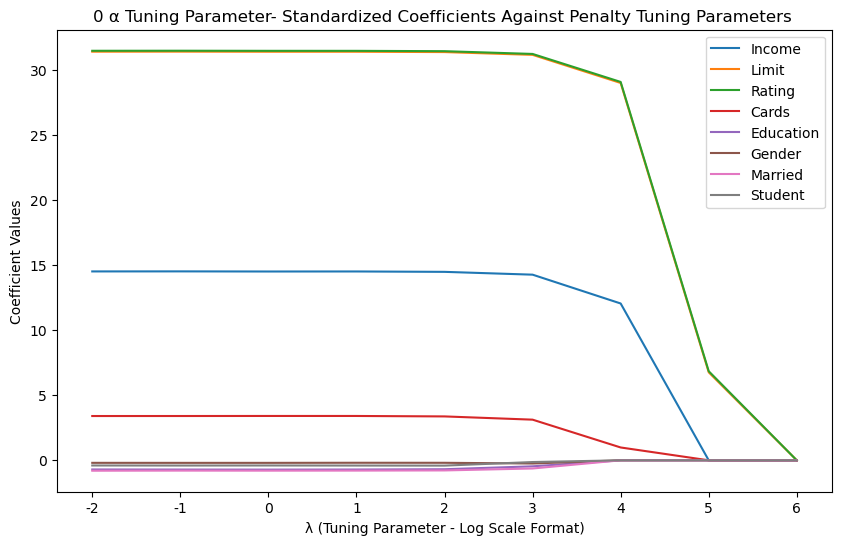

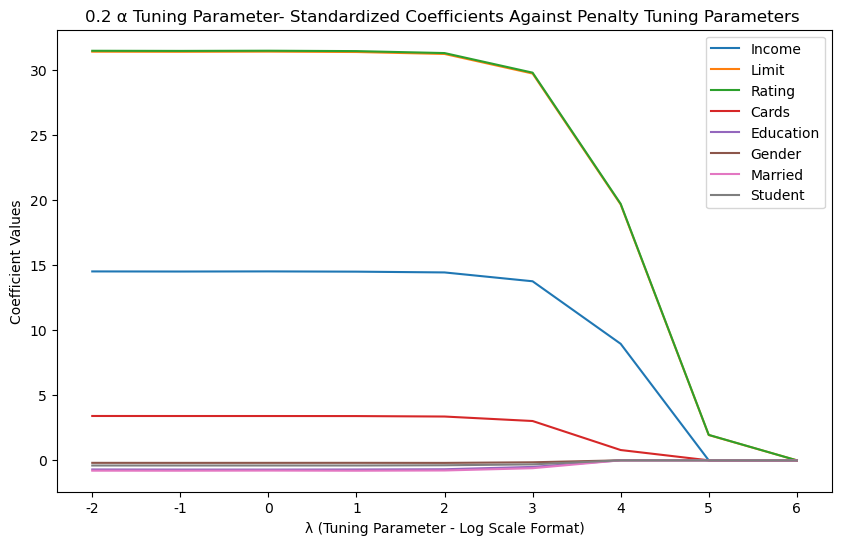

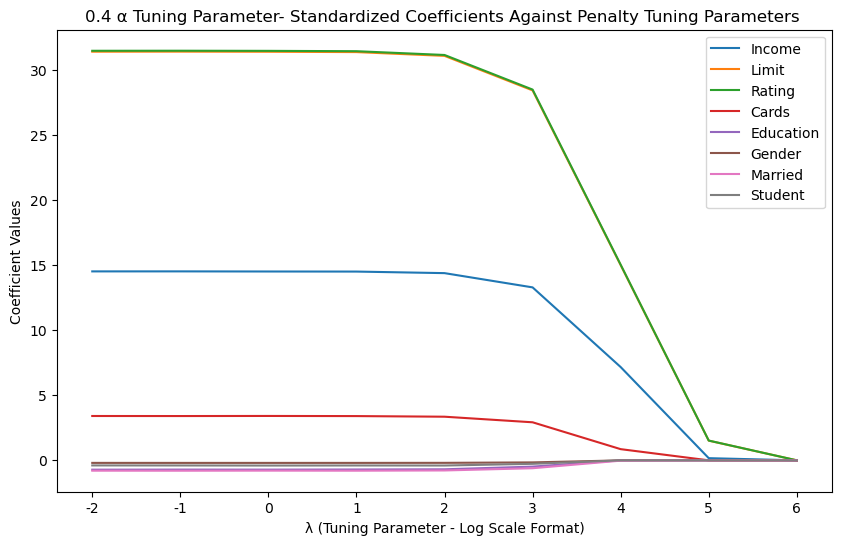

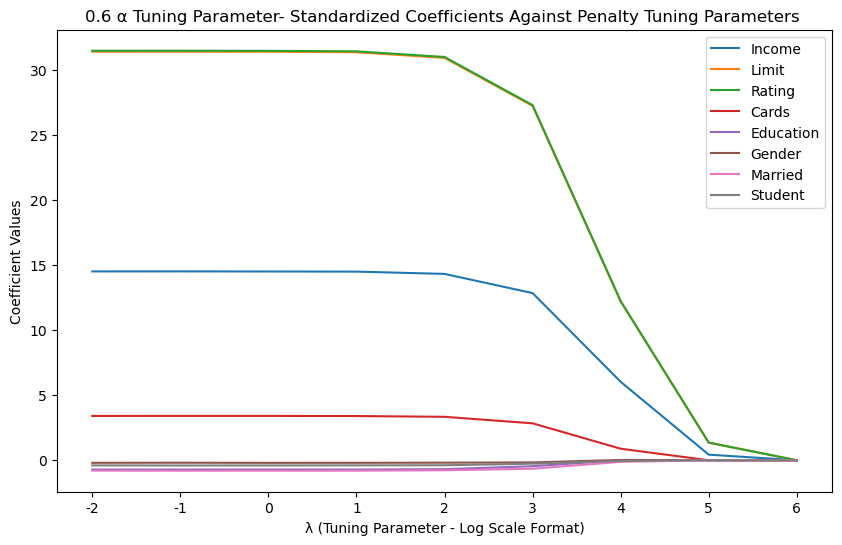

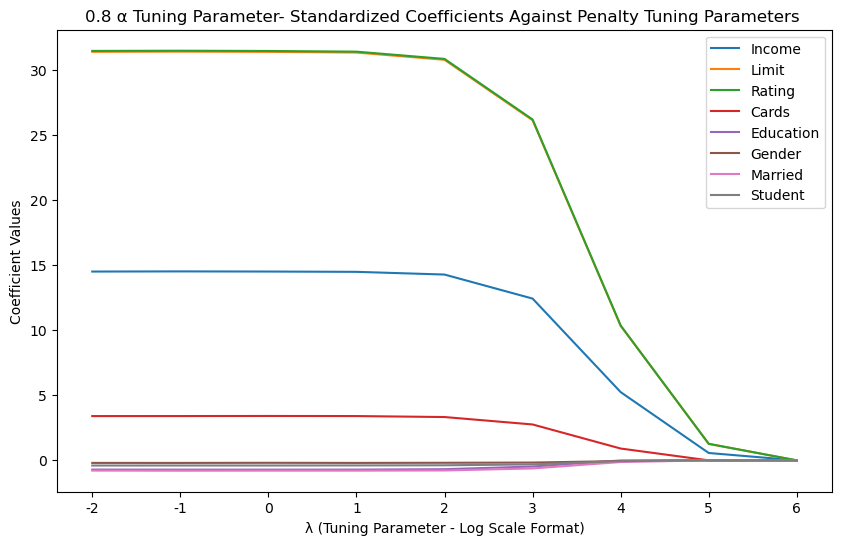

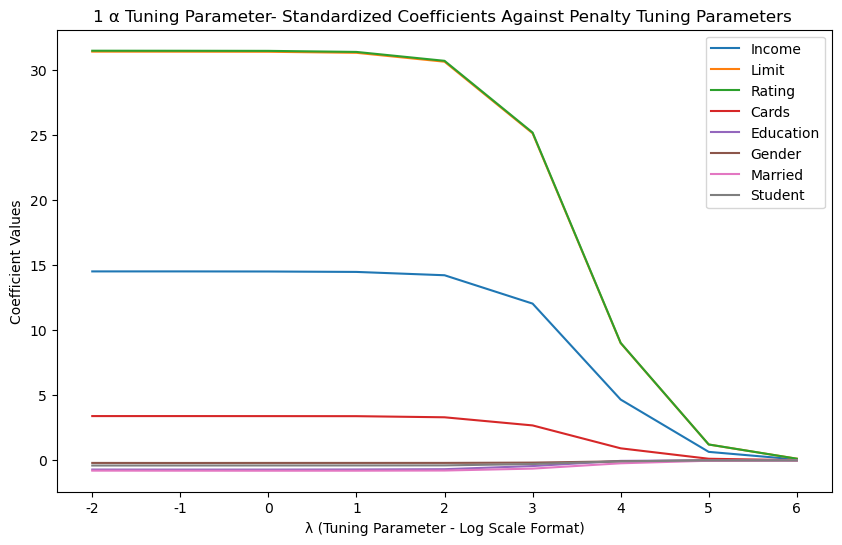

In [15]:
for current_graph_etp in range(len(elastic_tuning_parameter_set)):
    current_vector_param_b = etp_cross_validation_beta_account_final[current_graph_etp]
    
    graph_title = str(elastic_tuning_parameter_set[current_graph_etp]) + " α Tuning Parameter- Standardized Coefficients Against Penalty Tuning Parameters "
    coeffecientsvptp(current_vector_param_b,  graph_title)
    

# __________________________________________________________________
# __________________________________________________________________

In [16]:
def errorvpenaltyperetp(cv_account_current, graph_title):
    tp_log_set = [-2,-1,0,1,2,3,4,5,6]
    #This graph shows the cross validation error scores across all of the penalty terms
    plt.figure(figsize=(10, 6))
    plt.semilogx(tuning_parameters_set, cv_account_current, 'bo-')
    plt.xticks(ticks=tuning_parameters_set, labels=tp_log_set)
    plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
    plt.ylabel('Cross-Validation Error Scores')
    #plt.title('Cross-Validation Error Scores Against Penalty Parameters')
    plt.title(graph_title)
    plt.show()

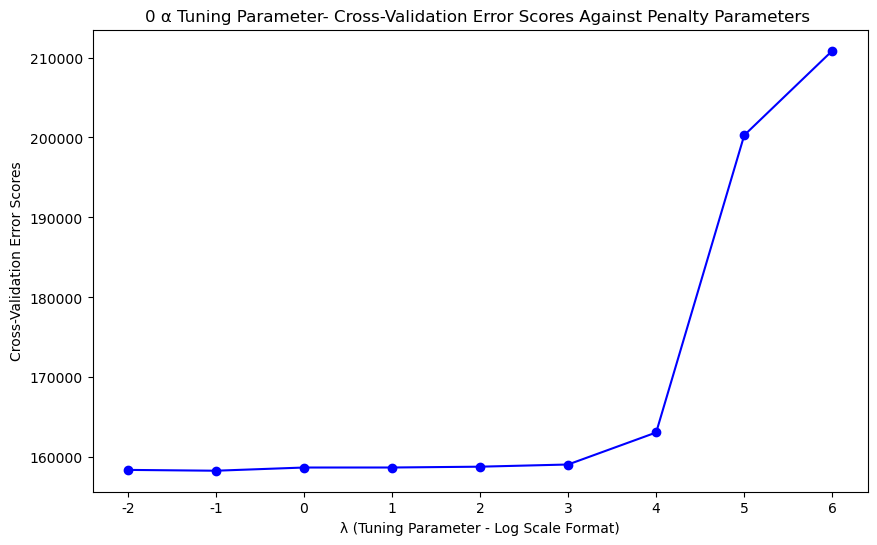

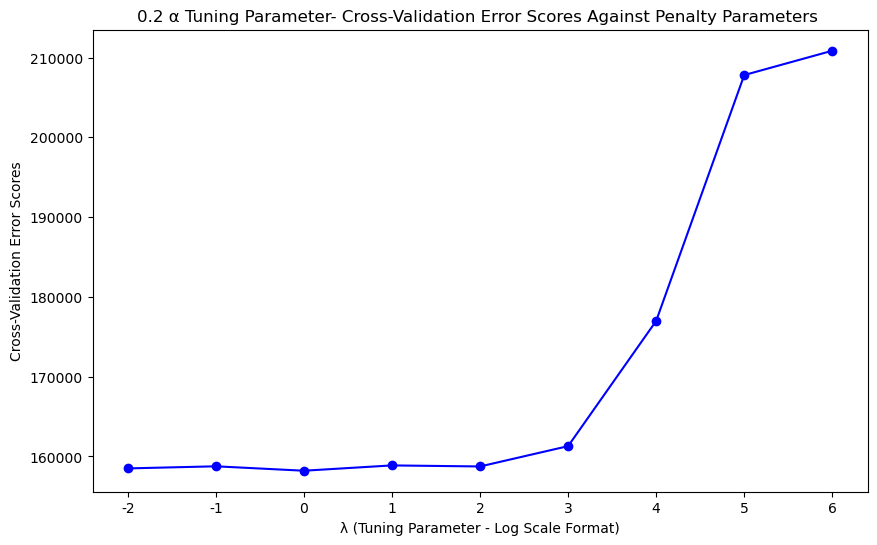

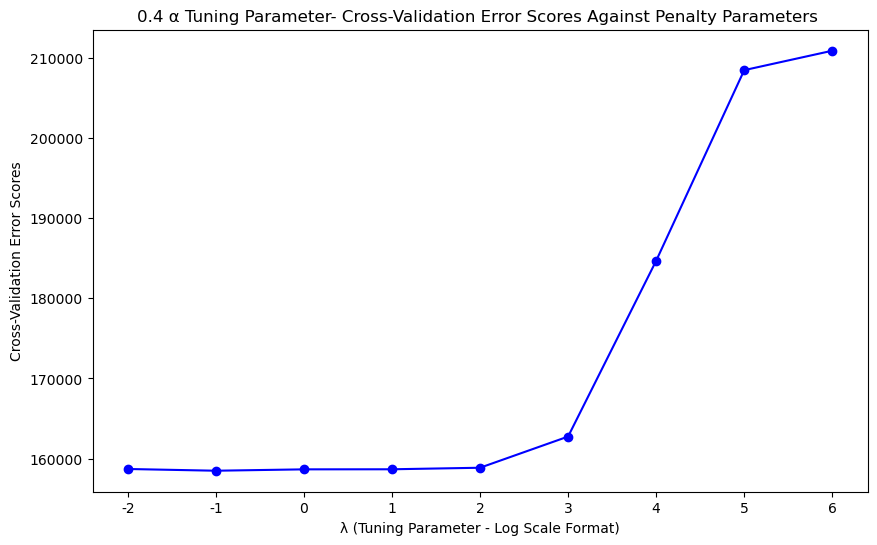

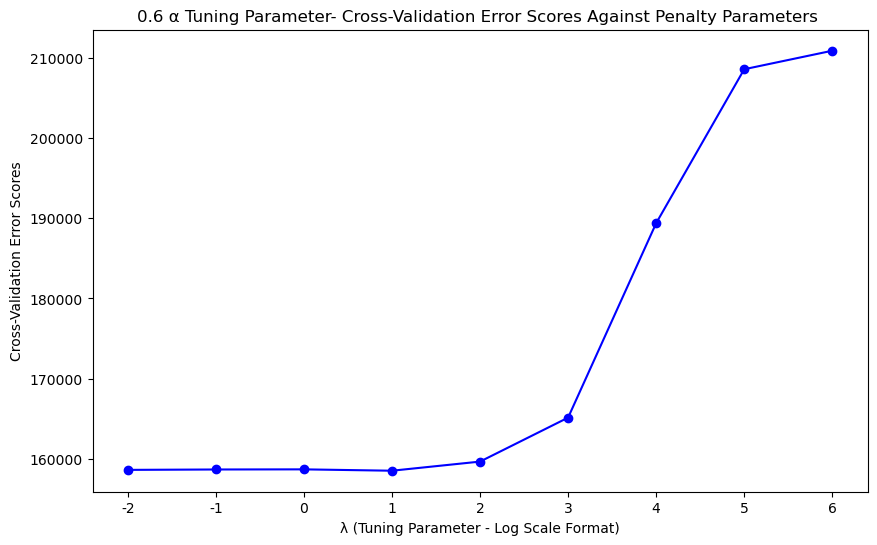

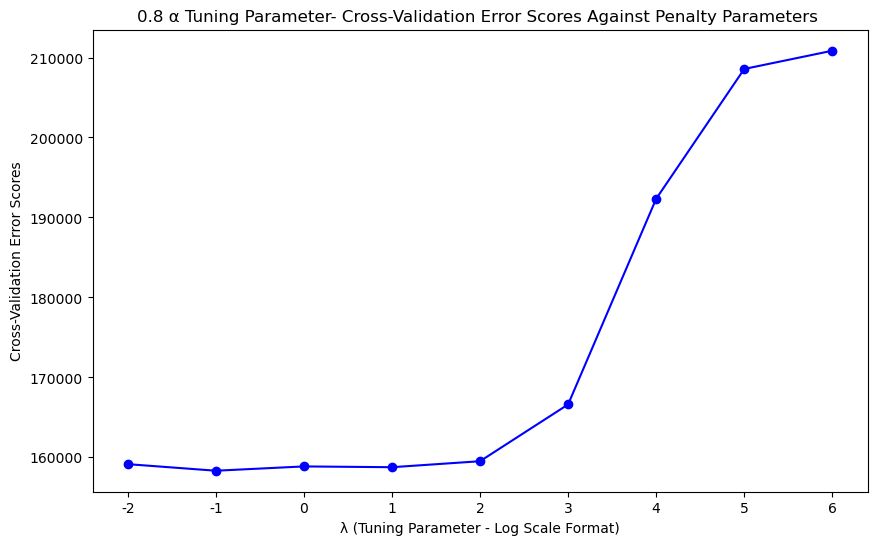

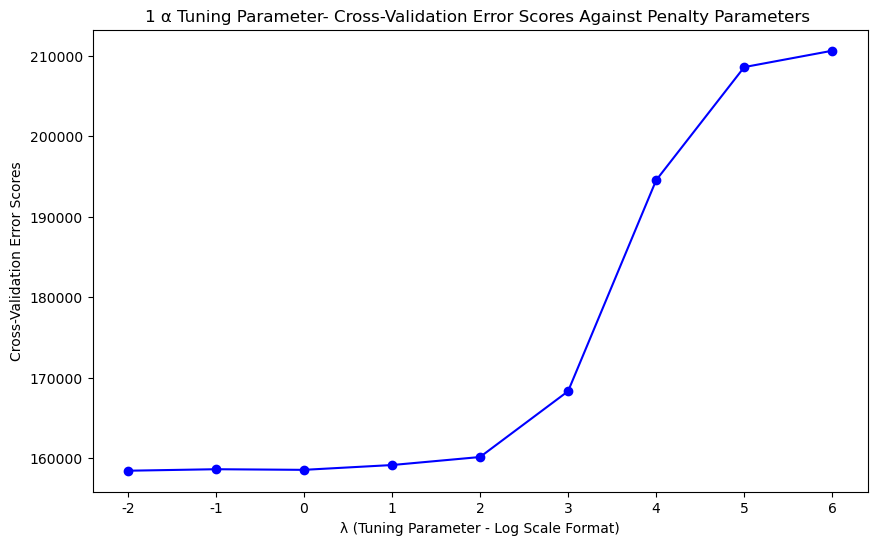

In [17]:
for current_graph_etp in range(len(elastic_tuning_parameter_set)):
    current_vector_param_b = etp_cross_validation_account_final[current_graph_etp]
    
    graph_title = str(elastic_tuning_parameter_set[current_graph_etp]) + " α Tuning Parameter- Cross-Validation Error Scores Against Penalty Parameters "
    errorvpenaltyperetp(current_vector_param_b,  graph_title)

# __________________________________________________________________
# __________________________________________________________________

In [18]:
lowest_cross_validation_errors = []
placeholder_cve = min(etp_cross_validation_account_final[0])


In [19]:
placerholder_etp_position = 0

In [20]:
                 
for current_etp in range(len(elastic_tuning_parameter_set)):
    lowest_cross_validation_error = min(etp_cross_validation_account_final[current_etp])
    if lowest_cross_validation_error < placeholder_cve:
                      placeholder_cve = lowest_cross_validation_error
                      placerholder_etp_position = current_etp
print("The lowest cross-validation error score achieved: " + str(placeholder_cve))
print("Alpha tuning parameter used " + str(elastic_tuning_parameter_set[placerholder_etp_position]))

The lowest cross-validation error score achieved: 158203.54743628483
Alpha tuning parameter used 0.2


In [21]:
#This lowest cross validation error score is used to get the the lambda parameter used to achieve this score
tuning_parameter_lowest_cv = 0

cva_final = etp_cross_validation_account_final[placerholder_etp_position]
for i in range(len(cva_final)):
    if cva_final[i] == placeholder_cve:
        tuning_parameter_lowest_cv = tuning_parameters_set[i]

print("The lambda parameter that resulted in the lowest cross-validation score: " + str(tuning_parameter_lowest_cv))
#print(tuning_parameter_lowest_cv)


The lambda parameter that resulted in the lowest cross-validation score: 1


# __________________________________________________________________
# __________________________________________________________________

In [22]:
# __________________________________________________________________
# __________________________________________________________________